# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [2]:

# Load the dataset
df = pd.read_csv('colorectal_cancer_prediction.csv')

# Display basic information about the dataset

print("--- Dataset Dimensions ---")

print(f"Data shape: {df.shape}\n")

print("--- Datatype Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Dimensions ---
Data shape: (89945, 30)

--- Datatype Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 


## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

--- Check for missing values ---
Patient_ID                 0
Age                        0
Gender                     0
Race                       0
Region                     0
Urban_or_Rural             0
Socioeconomic_Status       0
Family_History             0
Previous_Cancer_History    0
Stage_at_Diagnosis         0
Tumor_Aggressiveness       0
Colonoscopy_Access         0
Screening_Regularity       0
Diet_Type                  0
BMI                        0
Physical_Activity_Level    0
Smoking_Status             0
Alcohol_Consumption        0
Red_Meat_Consumption       0
Fiber_Consumption          0
Insurance_Coverage         0
Time_to_Diagnosis          0
Treatment_Access           0
Chemotherapy_Received      0
Radiotherapy_Received      0
Surgery_Received           0
Follow_Up_Adherence        0
Survival_Status            0
Recurrence                 0
Time_to_Recurrence         0
dtype: int64


--- Visualization ---



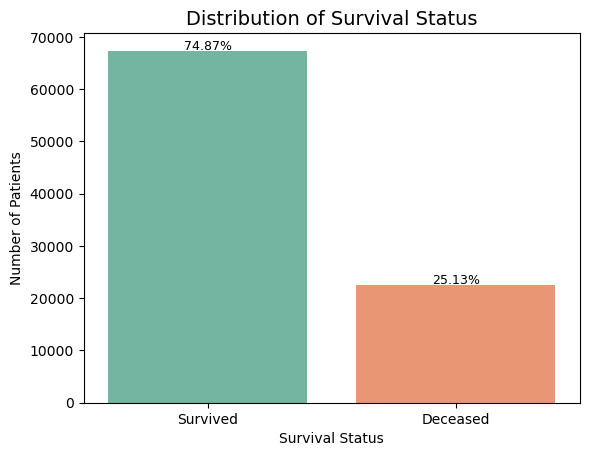

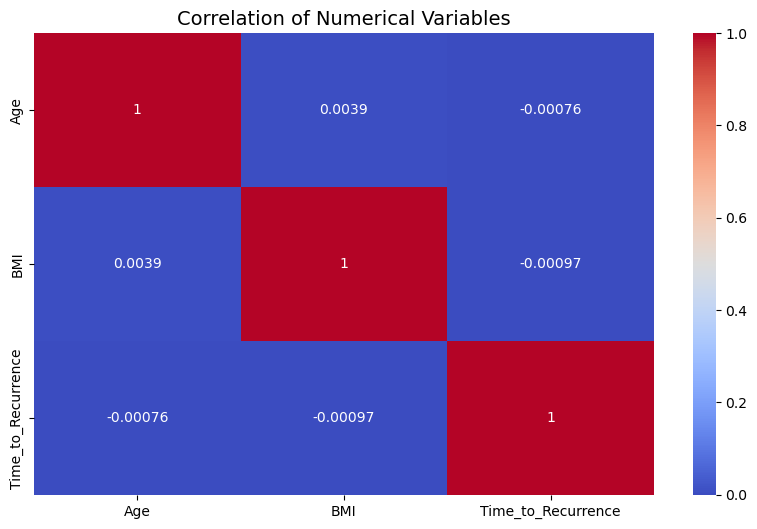

In [3]:

# Check for missing values

print("--- Check for missing values ---")
print(df.isnull().sum())

# remove null(if any)
df = df.dropna(subset=['Patient_ID'])


# Visualize survival status distribution

print("\n\n--- Visualization ---\n")

ax = sns.countplot(data= df, x='Survival_Status', hue= 'Survival_Status', palette='Set2', legend=False)
plt.title('Distribution of Survival Status', fontsize=14)
plt.xlabel('Survival Status')
plt.ylabel('Number of Patients')

# Calculating total number of rows in the dataset to get percentage base
total_patients = len(df)

for a in ax.patches:
    height = a.get_height() # Gets the height of the bar
    
    # Label bars
    if height > 0:
        percentage = (height / total_patients) * 100
        percentage_text = f'{percentage:.2f}%'
        
        ax.text(
            a.get_x() + a.get_width() / 2.,  # X position: center of the bar
            height + 200,                    # Y position: slightly above the bar height
            percentage_text,
            ha= "center",
            fontsize= 9,
            color= 'black'
        )
plt.show()

# Correlation heatmap (numerical features only)

plt.figure(figsize=(10,6))
df_numeric = df.drop(columns = ['Patient_ID'])
corr = df_numeric.corr(numeric_only= True)
sns.heatmap(corr, annot= True, cmap='coolwarm')
plt.title('Correlation of Numerical Variables', fontsize=14)
plt.show()

* *As we can see the Numerical columns have no significant correlation to eachother.*
* *And after doing Exploratory Data Analysis (EDA) of these columns using boxplot. It is concluded that Numerical Columns have no strong Predictive signal.* 

In [4]:
#Exploratory Data Analysis (EDA) of categorical variables

import itertools
cat_col= ['Stage_at_Diagnosis', 'Chemotherapy_Received', 'Diet_Type', 'Smoking_Status','Alcohol_Consumption', 'Red_Meat_Consumption',
          'Fiber_Consumption', 'Insurance_Coverage','Time_to_Diagnosis','Treatment_Access', 'Radiotherapy_Received', 'Surgery_Received', 
         'Gender', 'Race','Region', 'Urban_or_Rural', 'Socioeconomic_Status', 'Family_History', 'Previous_Cancer_History']
for combo in itertools.combinations(cat_col, 3):
    col1, col2, col3 = combo

    cross = pd.crosstab([df[col1], df[col2], df[col3]], df['Survival_Status'], normalize= 'index')

    if cross['Survived'].var()>0.001:
            print(f"--- 3-way Pattern Found: {col1}, {col2}, {col3} ---")
            print(cross)
            print("\n")

## Conclusion

* *As the above code prints nothing (the result remained consistent with baseline distribution of 75% survival rate), it proves that the Dataset is lacking the necessary predictive variance to support a high-accuracy classification model*

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [5]:

# Drop unnecessary columns (e.g., Patient ID if present)
df = df.drop(columns=['Patient_ID'], errors='ignore')


# Encode categorical variables
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Survival_Status' in cat_cols:
    cat_cols.remove('Survival_Status')
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


# Define features and target variable
  # Adjust target column name as needed
if df_encoded['Survival_Status'].dtype == 'object':
    df_encoded['Survival_Status'] = df_encoded['Survival_Status'].map({'Survived': 1, 'Deceased': 0})

X = df_encoded.drop(columns=['Survival_Status'])
y = df_encoded['Survival_Status']
print("--- Feature Variables ---")
F_list = X.columns.tolist()
for index, feature in enumerate(F_list, start= 1):
    print(f'{index}. {feature}')

print(f"\n Target Variable: {y.name}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


--- Feature Variables ---
1. Age
2. BMI
3. Time_to_Recurrence
4. Gender_Male
5. Race_Black
6. Race_Hispanic
7. Race_Other
8. Race_White
9. Region_Asia Pacific
10. Region_Europe
11. Region_Latin America
12. Region_North America
13. Urban_or_Rural_Urban
14. Socioeconomic_Status_Low
15. Socioeconomic_Status_Middle
16. Family_History_Yes
17. Previous_Cancer_History_Yes
18. Stage_at_Diagnosis_II
19. Stage_at_Diagnosis_III
20. Stage_at_Diagnosis_IV
21. Tumor_Aggressiveness_Low
22. Tumor_Aggressiveness_Medium
23. Colonoscopy_Access_Yes
24. Screening_Regularity_Never
25. Screening_Regularity_Regular
26. Diet_Type_Traditional
27. Diet_Type_Western
28. Physical_Activity_Level_Low
29. Physical_Activity_Level_Medium
30. Smoking_Status_Former
31. Smoking_Status_Never
32. Alcohol_Consumption_Low
33. Alcohol_Consumption_Medium
34. Red_Meat_Consumption_Low
35. Red_Meat_Consumption_Medium
36. Fiber_Consumption_Low
37. Fiber_Consumption_Medium
38. Insurance_Coverage_Yes
39. Time_to_Diagnosis_Timely
40. 

## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [6]:

# Train a Logistic Regression model

model = LogisticRegression(max_iter=1000, class_weight= 'balanced')
model.fit(X_train, y_train)

# Predictions

y_pred = model.predict(X_test)

# Model evaluation
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))


print(f"Model Accuracy: {accuracy_score(y_test, y_pred)* 100:.2f}%\n")
print("Classification Report:\n\n", classification_report(y_test, y_pred))


Model Accuracy: 50.56%

Classification Report:

               precision    recall  f1-score   support

           0       0.26      0.50      0.34      4521
           1       0.75      0.51      0.61     13468

    accuracy                           0.51     17989
   macro avg       0.50      0.51      0.47     17989
weighted avg       0.63      0.51      0.54     17989

